# Project Pt. 2: Evaluating Player Performance and Salary Value in the NBA (1950–2023)
## Team Members
- Ashley Kang: ashleykg
- Chloe Yueh: yyueh
- Min-Yi Chen: minyi

## Descriptive Statistics - ASHLEY

In [1]:
# import necessary packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import ttest_ind, f_oneway, tukey_hsd



In [2]:
# read in the merged dataframe created from part 1 of the project
merged_df = pd.read_csv("merged_data.csv")

In [3]:
# these are our key variables
key_vars = ['Age', 'PTS', 'FG%', 'inflationAdjSalary']
stats = merged_df[key_vars].describe()

# mean, median, mode, range, sd, variance
mean_vals = merged_df[key_vars].mean()
median_vals = merged_df[key_vars].median()
mode_vals = merged_df[key_vars].mode()
min_vals = merged_df[key_vars].min()
max_vals = merged_df[key_vars].max()
range_vals = max_vals - min_vals
std_vals = merged_df[key_vars].std()
var_vals = std_vals ** 2

# print statistics
print("========= Summary Statistics =========")
print(stats)

print("\n========= Means =========")
print(mean_vals)

print("\n========= Medians =========")
print(median_vals)

print("\n========= Mode =========")
print(mode_vals)

print("\n========= Min =========")
print(min_vals)

print("\n========= Max =========")
print(max_vals)

print("\n========= Range =========")
print(range_vals)

print("\n========= Standard Deviations =========")
print(std_vals)

print("\n========= Variation =========")
print(var_vals)

========= Summary Statistics =========
                Age           PTS           FG%  inflationAdjSalary
count  13604.000000  13604.000000  13604.000000        1.360400e+04
mean      26.739929    545.498824      0.447186        6.424900e+06
std        4.102379    468.737462      0.076080        7.306459e+06
min       18.000000      0.000000      0.000000        4.824000e+03
25%       24.000000    170.000000      0.408761        1.696499e+06
50%       26.000000    423.000000      0.444444        3.730078e+06
75%       30.000000    810.000000      0.484730        8.248559e+06
max       43.000000   2832.000000      1.000000        6.125856e+07

========= Means =========
Age                   2.673993e+01
PTS                   5.454988e+02
FG%                   4.471865e-01
inflationAdjSalary    6.424900e+06
dtype: float64

========= Medians =========
Age                   2.600000e+01
PTS                   4.230000e+02
FG%                   4.444444e-01
inflationAdjSalary    3.730078e+0

The guiding questions tha we developed in Part I of the project are: 

1. Does a higher salary guarantee better performance efficiency?
2. Is there a correlation between player salary and age?
3. Do more consistent players earn higher salaries than less consistent players?

To address these questions, we focused on these key variables in the dataset:

1. inflationAdjSalary (player salary),
2. FG% (Field Goal Percentage) as a measure of efficiency,
3. PTS (points scored) as a measure of performance, and
4. Age of the player.

We began by examining summary statistics for these variables to understand their distributions and variability.

---
**RQ1: Does a higher salary guarantee better performance efficiency?**

The results show that salary has a high level of variation, with a standard deviation of approximately $7.3 million, which is larger than the mean ($6.4 million). In contrast, FG% exhibits relatively low variation, with a standard deviation of 0.076, indicating that the efficiency is fairly consistent across players. 

These findings suggest that higher salaries do not guarantee better efficiency. While salaries vary widely, the goal efficiency remains relatively stable, implying that factors other than efficiency, such as scoring volume or the role of the player, might play a larger role in determining the salary.

---
**RQ2: Is there a correlation between player salary and age?**

The distribution fo the Age variable is tight, with a standard deviation of 4.1 years, whereas salary varies substantially, with a range of approximately $61 million. This indicates that age alone is unlikely to be a strong predictor of salary, as it does not vary nearly as much. Additionally, the median age is 26, mode age is 23, minimum is 18, and maximum is 43. This suggests a likely pattern: younger players may earn lower salaries due to rookie contracts, while older players may have more varied salaries depending on experience and performance. And players in their prime years (mid to late 20s) are likely to earn higher salaries. 

Overall, this suggests that there might be a non-linear relationship between age and salary, which can be further explored through visualizations. 

---
**RQ3: Do more consistent players earn higher salaries than less consistent players?**

To determine the consistency of players, we decided to measure it by using the standard deviation of players' points. A lower standard deviation would indicate a more consistent performance, while a higher standard deviation would reflect a greater variability in scoring. 

Based on our results, the standard deviation of PTS (469) indicates substantial variability in scoring across players. Similarly, salary also shows high variability, with a standard deviation of $7.3 million. Although these results demonstrate that players differ significantly in both performance consistency and salary, there is no clear evidence from the summary statistics alone that says consistent players earn higher salaries. This relationship also requires further investigation through visualizations. 

---
**Overall Observations**

The distribution of salary and PTS are right-skewed, meaning a small number of players earn significantly higher salaries and score substantially more points than the average. As a result, the median is a more reliable measure of central tendency than the mean for these variables. 

Additionally, there appears to be outliers in the dataset, such as the maximum FG% value of 1.0, which likely represents an unrealistic edge case. These outliers may influence the results and should be considered when interpreting the findings.

## Inferential Statistics - MINYI

In this section, we will run statistical tests to directly answer the three research questions we framed in Part I. We will evaluate predictive relationships and test for group differences.

### 1. Linear Regression: Efficiency (FG%) vs. Salary
Our first question asks if higher efficiency guarantees a higher salary. We use a Linear Regression model to test how well field goal percentage (FG%) predicts inflation-adjusted salary.

Objective: To see if FG% explains a significant amount of the variance in a player's salary, and to evaluate the prediction error using R-squared and RMSE.

In [4]:
# linear regression: FG% vs Salary
# clean data by dropping rows with missing values in FG% or inflationAdjSalary
rq1_df = merged_df[['FG%', 'inflationAdjSalary']].dropna()

# define X and y for regression
X = rq1_df[['FG%']] # X needs to be 2D for sklearn, so we use double brackets to get a DataFrame
y = rq1_df['inflationAdjSalary']

# fit linear regression model
model = LinearRegression()
model.fit(X, y)

# make predictions and calculate metrics
y_pred = model.predict(X)

# calculate R² and RMSE
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("=== Linear Regression Results ===")
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Equation: Salary = {model.intercept_:.2f} + {model.coef_[0]:.2f} × FG%")
print(f"Interpretation: Each 1% increase in FG% → ${model.coef_[0] / 100:.2f} increase in Salary")
print(f"\nR² = {r2:.3f} → explains {r2*100:.1f}% of variance")
print(f"RMSE = {rmse:.3f} → predictions typically off by ${rmse:.2f}")

=== Linear Regression Results ===
Coefficient (Slope): 13310939.74
Intercept: 472427.61
Equation: Salary = 472427.61 + 13310939.74 × FG%
Interpretation: Each 1% increase in FG% → $133109.40 increase in Salary

R² = 0.019 → explains 1.9% of variance
RMSE = 7235672.265 → predictions typically off by $7235672.26


### Interpretation of RQ1: Efficiency vs. Salary

**Practical Significance ($R^2$ and RMSE):**
Our linear regression model tested whether a player's shooting efficiency (FG%) predicts their salary. The results strongly confirm our initial observations from the descriptive statistics:

* R² (1.9%): Field goal percentage explains a mere 1.9% of the variance in players' salaries. This is an extremely weak relationship, meaning that a player's efficiency is practically useless for predicting how much they are paid.
* RMSE (~$7.24M): When trying to predict a player's salary based solely on their FG%, our predictions are typically off by over $7.2 million.

Conclusion for RQ1:
Does a higher salary guarantee better performance efficiency? The statistical answer is **no**. A high salary does not guarantee high efficiency, and high efficiency does not guarantee a high salary. Teams likely pay for the overall volume of production (like total points) or specific team roles, rather than just shooting accuracy alone.

### 2. Group Comparisons: Age vs. Salary

Our second question asks if there is a relationship between a player's age and their salary. As noted in Part 1, we suspect a non-linear relationship where players in their prime earn the most. To test this, we divided players into three age groups: Rookie (<24), Prime (24-29), and Veteran (30+). We will use a One-Way ANOVA to compare their average salaries.

* Null Hypothesis (H0): There is no significant difference in average salary across the three age groups.
* Alternative Hypothesis (H1): At least one age group has a significantly different average salary.
* Significance level (α): 0.05

In [5]:
rq2_df = merged_df[['Age', 'inflationAdjSalary']].dropna().copy()
# create age groups: Rookie (<24), Prime (24-29), Veteran (30+)
conditions = [
    (rq2_df['Age'] < 24),
    (rq2_df['Age'] >= 24) & (rq2_df['Age'] <= 29),
    (rq2_df['Age'] > 29)
]
# assign labels to age groups
choices = ['1_Rookie (<24)', '2_Prime (24-29)', '3_Veteran (30+)']
# create new column 'Age_Group' based on conditions
rq2_df['Age_Group'] = np.select(conditions, choices, default='Other')

# separate salaries by age group
rookie_salary = rq2_df[rq2_df['Age_Group'] == '1_Rookie (<24)']['inflationAdjSalary']
prime_salary = rq2_df[rq2_df['Age_Group'] == '2_Prime (24-29)']['inflationAdjSalary']
veteran_salary = rq2_df[rq2_df['Age_Group'] == '3_Veteran (30+)']['inflationAdjSalary']

# perform one-way ANOVA for Salary by Age Group
f_stat, p_val = f_oneway(rookie_salary, prime_salary, veteran_salary)

print("=== One-Way ANOVA Results: Salary by Age Group ===")
print(f"F-statistic: {f_stat:.3f}")
print(f"p-value: {p_val:.4f}")

print("\nInterpretation:")
if p_val < 0.05:
    print("p < 0.05: At least one group differs from the others.")
    print("Need post-hoc test to identify which groups differ.")
else:
    print("p ≥ 0.05: No evidence of differences among groups.")

# calculate and print average salary by position
print("\n=== Average Salary by Age Group ===")
print(rq2_df.groupby('Age_Group')['inflationAdjSalary'].mean().sort_values(ascending=False).apply(lambda x: f"${x:,.2f}"))




=== One-Way ANOVA Results: Salary by Age Group ===
F-statistic: 312.364
p-value: 0.0000

Interpretation:
p < 0.05: At least one group differs from the others.
Need post-hoc test to identify which groups differ.

=== Average Salary by Age Group ===
Age_Group
3_Veteran (30+)    $7,950,012.43
2_Prime (24-29)    $6,924,144.66
1_Rookie (<24)     $3,862,504.00
Name: inflationAdjSalary, dtype: object


In [6]:
# perform Tukey's HSD post-hoc test to identify which age groups differ
result = tukey_hsd(rookie_salary, prime_salary, veteran_salary)
age_groups = ['1_Rookie (<24)', '2_Prime (24-29)', '3_Veteran (30+)']
print("Pairwise Comparisons (Tukey's HSD):")
print("="*40)

for i in range(len(age_groups)):
    for j in range(i+1, len(age_groups)):
        p = result.pvalue[i, j]
        sig = "*" if p < 0.05 else "ns"
        print(f"{age_groups[i]:4s} vs {age_groups[j]:4s}: p = {p:.4f} {sig}")

print("\n* = significant at p < 0.05, ns = not significant")

Pairwise Comparisons (Tukey's HSD):
1_Rookie (<24) vs 2_Prime (24-29): p = 0.0000 *
1_Rookie (<24) vs 3_Veteran (30+): p = 0.0000 *
2_Prime (24-29) vs 3_Veteran (30+): p = 0.0000 *

* = significant at p < 0.05, ns = not significant


### Interpretation of RQ2: Age vs. Salary

**Hypothesis testing Conclusion:**
The One-Way ANOVA yielded a p-value of 0.0000. Since this is well below our 0.05 threshold, we easily reject the Null Hypothesis (H0). There is a statistically significant difference in salaries across the three age groups.

**Post-Hoc Test findings:**

The Tukey's HSD test confirms that all three age groups are significantly different from one another (all p-values < 0.05). Interestingly, the data adds a nuance to our initial assumption:

* Rookies (<24) earn the least on average (~$3.86M). This perfectly aligns with our expectation, as younger players are restricted by entry-level rookie-scale contracts.
* Prime (24-29) players see a massive jump in earnings (~$6.92M) as they sign their first major post-rookie extensions.
* Veterans (30+) actually hold the highest average salary (~$7.95M). While players might biologically peak in their mid-twenties, this reflects a survivorship bias in the NBA: players who manage to stay in the league past age 30 are typically highly valuable stars or established contributors who command large veteran contracts, whereas less talented players have already washed out of the league.

### 3. Linear Regression: Consistency vs. Salary

Our final research question explores whether scoring consistency leads to higher salaries. We measure a player's consistency by calculating the standard deviation of their total points (PTS) across their career seasons. A lower standard deviation implies a more consistent scoring output.

We will use a Linear Regression model to test if a player's scoring consistency (PTS Standard Deviation) predicts their average inflation-adjusted salary. To ensure the standard deviation is meaningful, we will only include players who have played at least 3 seasons.

Objective: To determine if scoring consistency (PTS std) explains a significant amount of the variance in a player's average salary, and to evaluate the practical prediction error (RMSE).

In [7]:
# group by player to calculate scoring consistency (PTS standard deviation), average salary, and seasons played
player_stats = merged_df.groupby('player').agg({
    'PTS': 'std',                  # calculate PTS standard deviation (Consistency)
    'inflationAdjSalary': 'mean',  # calculate average salary
    'season': 'count'              # calculate total seasons played
}).rename(columns={'PTS': 'PTS_std', 'inflationAdjSalary': 'Avg_Salary', 'season': 'Seasons_Played'})

# only keep players with at least 3 seasons (so that standard deviation is meaningful), and drop rows with missing values
rq3_df = player_stats[player_stats['Seasons_Played'] >= 3].dropna()

# set X (PTS standard deviation) and y (average salary)
X_cons = rq3_df[['PTS_std']]
y_sal = rq3_df['Avg_Salary']

# build and fit linear regression model
model_rq3 = LinearRegression()
model_rq3.fit(X_cons, y_sal)

# make predictions and calculate metrics
y_pred_cons = model_rq3.predict(X_cons)
r2_cons = r2_score(y_sal, y_pred_cons)
rmse_cons = np.sqrt(mean_squared_error(y_sal, y_pred_cons))

print("=== RQ3: Linear Regression (Scoring Consistency vs Salary) ===")
print(f"Coefficient (Slope): {model_rq3.coef_[0]:.2f}")
print(f"Intercept: {model_rq3.intercept_:.2f}")
print(f"Equation: Salary = {model_rq3.intercept_:.2f} + {model_rq3.coef_[0]:.2f} × PTS_std")
print(f"Interpretation: Each 1 point increase in PTS_std → ${model_rq3.coef_[0]:.2f} increase in Salary")
print(f"\nR² = {r2_cons:.3f} → explains {r2_cons*100:.1f}% of variance")
print(f"RMSE = {rmse_cons:.3f} → predictions typically off by ${rmse_cons:.2f}")

=== RQ3: Linear Regression (Scoring Consistency vs Salary) ===
Coefficient (Slope): 19875.88
Intercept: 407688.57
Equation: Salary = 407688.57 + 19875.88 × PTS_std
Interpretation: Each 1 point increase in PTS_std → $19875.88 increase in Salary

R² = 0.327 → explains 32.7% of variance
RMSE = 4237596.906 → predictions typically off by $4237596.91


### Interpretation of RQ3: Consistency vs. Salary

**Practical Significance ($R^2$ and RMSE):**
Our linear regression model tested whether a player's scoring consistency (measured by the standard deviation of their points) could predict their average salary. 

* R² (32.7%): The model explains 32.7% of the variance in salary. However, we must interpret this carefully.
* Slope (Positive): The regression slope is positive (~$19,875). This counter-intuitively means that a *higher* standard deviation (i.e., being *less* consistent) is associated with a *higher* salary. 
* RMSE (~$4.23M): The prediction error remains massive at over $4.2 million, indicating a very noisy relationship.

Conclusion for RQ3:

Do more consistent players earn higher salaries? The statistical evidence says **no**. In fact, players with higher scoring variability tend to earn more. 

This reveals a hidden factor: the total points a player scores. A bench player who consistently scores fewer points every game will have a standard deviation near zero (extremely consistent) but earn a minimum salary. On the other hand, a superstar who averages 25 points might score 15 in one game and 40 in another. This results in a massive standard deviation (highly inconsistent mathematically) but a maximum salary.

Therefore, teams do not pay for mathematical consistency; they pay for the overall points and impact. The standard deviation here is largely acting as a proxy for how much a player scores rather than true reliability. We will visualize this relationship further with a scatter plot in the next section to confirm this pattern.

## Graphical Analysis - ASHLEY

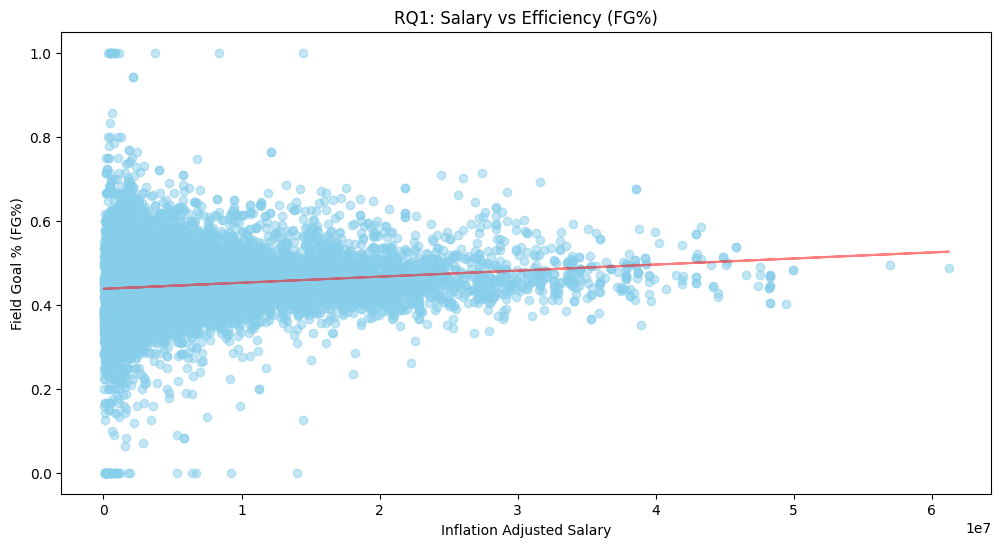

In [8]:
# plot for Research Question 1

x = merged_df['inflationAdjSalary']
y = merged_df['FG%']

plt.figure(figsize=(12,6))
plt.scatter(x, y, color='skyblue', alpha=0.5)

# line of best fit
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', alpha=0.5)

plt.xlabel('Inflation Adjusted Salary')
plt.ylabel('Field Goal % (FG%)')
plt.title('RQ1: Salary vs Efficiency (FG%)')

plt.show()

**Interpretation (RQ1: Salary v. Efficiency)**

From this plot, there appears to be a weak correlation between salary and shooting efficiency (FG%). While the line of best fit shows a slight upward trend, indicating a weak positive relationship, the slope is very small, and the overall pattern is scattered. 

A large concentration of players is clustered on the left side of the plot, representing lower-salary players, yet their field goal percentages vary widely. This suggests that players with lower salaries can still achieve both high and low efficiency levels. Similarly, players with higher salaries do not consistently exhibit significantly higher efficiency. 

Although there is a small upward trend, which means that the efficiency tends to increase slightly as salary increases, the relationship is not strong or consistent. The wide vertical spread of points at nearly all salary levels indicates a substantial variability in efficiency regardless of salary. 

Additionally, there are a few outliers, such as players with extremely high FG% values, which are likely due to limited sample sizes rather than the true performance. So these outliers further highlight that efficiency efficiency alone is not a primary determinant of salary. 

Overall, the visualization suggests that higher salary does not guarantee better performance efficiency. Instead, salary is likely influenced by other factors, such as scoring volume, overall impact, or player role, rather than the field goal percentage alone. 

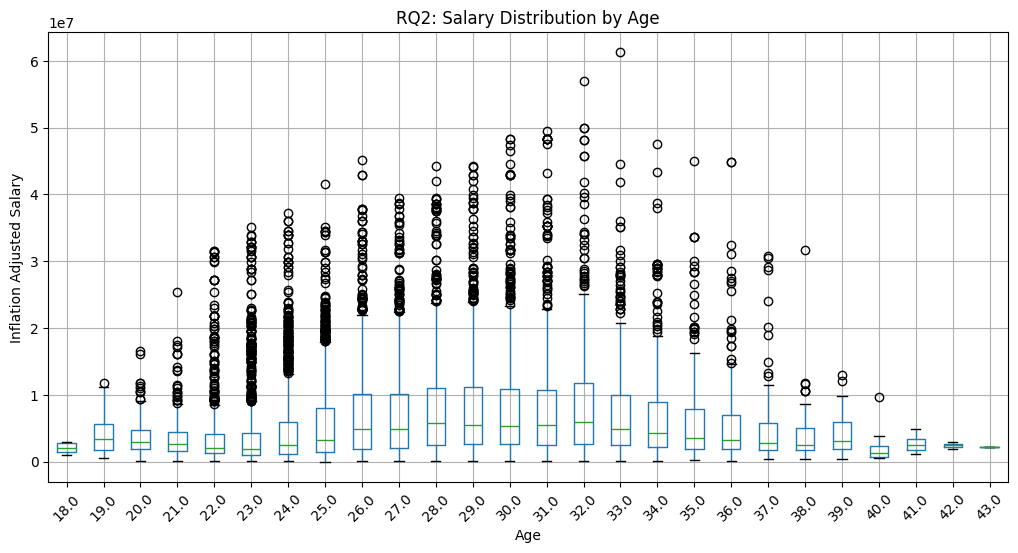

In [9]:
# plot for Research Question 2

fig, ax = plt.subplots(figsize=(12, 6))
merged_df.boxplot(column='inflationAdjSalary', by='Age', ax=ax)

ax.set_xlabel('Age')
ax.set_ylabel('Inflation Adjusted Salary')
ax.set_title('RQ2: Salary Distribution by Age')
plt.suptitle('')

plt.xticks(rotation=45)
plt.show()

**Interpretation (RQ2: age v. Salary)**

This boxplot illustrates the distribution of the inflation adjusted salaries across different ages, allowing us to visualize how salary varies throughout a player's career. 

Overall, the plot suggest a non linear relationship between age and salary. Salaries tend to increase from the early 20s into the late 20s and early 30s, where both the median salary and teh spread of salaries are higher. This indicates that players in their prime years (approximately ages 26-32) generally earn more and have greater earning potential. 

On the other hand, younger players (ages 18-22) show relatively lower medial salaries and tighter distributions, which is consistent with rookie contracts and limited experience. As players gain experience and establish their performance, we can see that their salaries increase accordingly. 

After the early 30s, there is a noticeable decline in both median salary and variability. This suggests that, while some older players continue to earn higher salaries, many experience a decrease in earnings, likely due to declining performance or reduced roles on teams due to new young players. 

The plot also reveals a significant number of outliers across nearly all age groups, particularly in the late 20s and early 30s. These high-salary outliers are likely representing the elite or famous players who earn substantially more than the average, and their presence is contributing to the wide spread of salaries observed in these age ranges. 

Overall, this visualization indicates that salary is not linearly correlated with age, but instead follows a career trajectory pattern: increasing during early career development, peaking during prime performance years, and declining in later years. This supports our conclusion that while age influences salary, it does so in a nonlinear and experience-dependent manner, rather than as a direct relationship.

In [10]:
# group my the players' names and create a new dataframe
player_std = merged_df.groupby('player')['PTS'].std().reset_index()
player_std.columns = ['player', 'PTS_std']

# Merge back salary (average salary per player)
player_salary = merged_df.groupby('player')['inflationAdjSalary'].mean().reset_index()

consistency_df = pd.merge(player_std, player_salary, on='player')
consistency_df.head()

,player,PTS_std,inflationAdjSalary
0,A.C. Green,342.907628,7.273038e+06
1,A.J. English,190.918831,7.830860e+05
2,A.J. Wynder,NaN,2.832380e+05
3,Aaron Brooks,410.337023,1.853551e+06
4,Aaron Gordon,348.519846,1.614793e+07


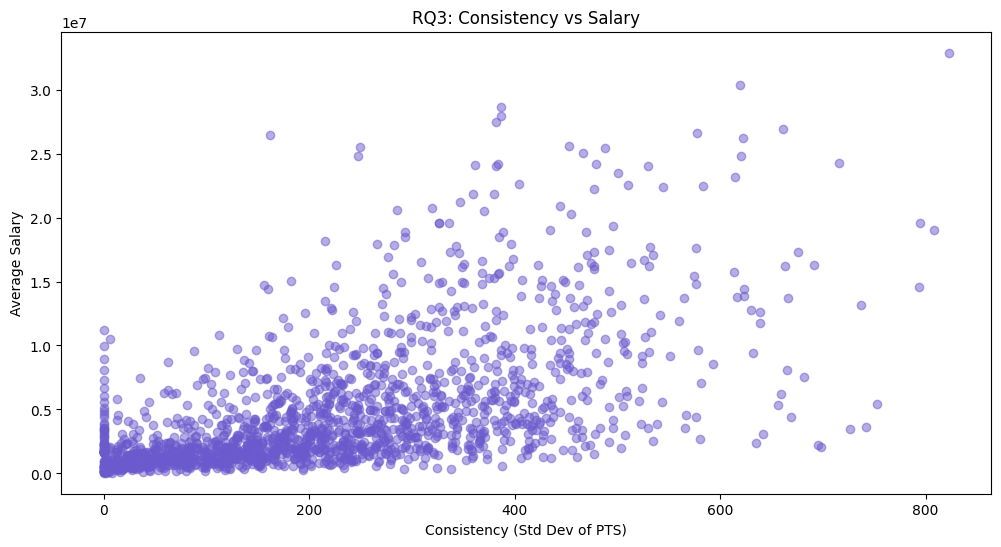

In [11]:
# plot for Research Question 3
plt.figure(figsize=(12, 6))

x = consistency_df['PTS_std']
y = consistency_df['inflationAdjSalary']

plt.scatter(x, y, color='slateblue', alpha=0.5)

plt.xlabel('Consistency (Std Dev of PTS)')
plt.ylabel('Average Salary')
plt.title('RQ3: Consistency vs Salary')

plt.show()

**Interpretation (RQ3: Consistency v. Avg Salary)**

This scatter plot examines the relationship between player consistency (measured by the standard deviation of points scored (PTS)) and the average salary. Overall, the plot shows no strong or clear linear relationship between consistency and salary. The data points are widely spread out, indicating that players with both low and high variability in scoring can earn a wide range or salaries. 

There is a noticeable concentration of players with low consistency values (lower standard deviation) and relatively lower salaries, suggesting that many consistent but lower-scoring players may occupy smaller roles or earn less. However, we can see that as the consistency values increase (more variability in scoring), the spread of salaries also increase significantly. 

An interesting pattern here is that some of the highest paid players appear at higher levels of variability, suggesting that players who score more but less consistently may still get high salaries. This implies that the overall scoring output or impact may be valued more in this relationship more than consistency alone. 

Additionally, the plot shows several outliers, particularly at higher consistency levels with very high salaries. These likely represent the star players whose performance includes high-scoring games that significantly impact the team's success. 

Overall, this visualization suggests that consistency alone is not a strong variable to determine and predict salary. While there may be a slight tendency for higher variability to be associated with higher salaries, the relationship is weak and inconsistent. This indicates that teams likely prioritize other factors, such as scoring ability and/or the player's role over consistency when determining salaries. 


## Comparative Analysis - MINYI

### Analysis 1: The evolution of the NBA (1990s vs. 2010s)

To fulfill the comparative analysis requirement, we will compare subsets of our data over time. The NBA has evolved significantly in terms of both playstyle (the modern 3-point boom) and financial structure (massive TV deal revenues).

We will segment our data into two distinct eras: the **1990s (1990-1999)** and the **2010s (2010-2019)**. We will use independent t-tests to compare the average scoring output (PTS) and the average inflation-adjusted salaries between these two decades.

* Null Hypothesis (H0): There is no significant difference in scoring and salaries between players in the 1990s and the 2010s.
* Alternative Hypothesis (H1): There is a significant difference in scoring and salaries between players in the 1990s and the 2010s.

In [12]:
# segement players into 1990s and 2010s for comparative analysis
df_1990s = merged_df[(merged_df['season'] >= 1990) & (merged_df['season'] <= 1999)].dropna(subset=['PTS', 'inflationAdjSalary'])
df_2010s = merged_df[(merged_df['season'] >= 2010) & (merged_df['season'] <= 2019)].dropna(subset=['PTS', 'inflationAdjSalary'])

# extract PTS and Salary for both groups
pts_90s, pts_10s = df_1990s['PTS'], df_2010s['PTS']
sal_90s, sal_10s = df_1990s['inflationAdjSalary'], df_2010s['inflationAdjSalary']
# perform t-tests to compare means of PTS and Salary between the two decades
t_stat_pts, p_val_pts = ttest_ind(pts_90s, pts_10s, equal_var=False)
t_stat_sal, p_val_sal = ttest_ind(sal_90s, sal_10s, equal_var=False)

# print comparative analysis results
print("=== Comparative Analysis: 1990s vs 2010s ===")
print("\n[1] Total Points (PTS) Comparison:")
print(f"1990s Avg PTS: {pts_90s.mean():.2f}")
print(f"2010s Avg PTS: {pts_10s.mean():.2f}")
print(f"t-statistic: {t_stat_pts:.3f}, p-value: {p_val_pts:.5e}")

print("\n[2] Inflation-Adjusted Salary Comparison:")
print(f"1990s Avg Salary: ${sal_90s.mean():,.2f}")
print(f"2010s Avg Salary: ${sal_10s.mean():,.2f}")
print(f"t-statistic: {t_stat_sal:.3f}, p-value: {p_val_sal:.5e}")

=== Comparative Analysis: 1990s vs 2010s ===

[1] Total Points (PTS) Comparison:
1990s Avg PTS: 586.71
2010s Avg PTS: 534.23
t-statistic: 4.950, p-value: 7.57457e-07

[2] Inflation-Adjusted Salary Comparison:
1990s Avg Salary: $3,706,759.77
2010s Avg Salary: $7,372,334.81
t-statistic: -26.608, p-value: 3.29203e-148


### Interpretation of Comparative Analysis 1

For both total points (PTS) and inflation-adjusted salaries, the independent t-tests yielded p-values well below our 0.05 significance level. Therefore, we cleanly reject the Null Hypothesis (H0) for both metrics. There is a statistically significant difference between the NBA in the 1990s and the 2010s.


The financial landscape of the NBA has drastically transformed. Even after adjusting for historical inflation, the average player salary essentially doubled from $3.707 million in the 1990s to ~$7.372 million in the 2010s. This massive surge is not due to standard economic inflation, but rather the league's global expansion and massive television broadcast rights deals, which directly increased the players' share of revenue.

Interestingly, while modern players are paid much more, the average total points (PTS) per player actually dropped from 587 in the 1990s to 534 in the 2010s. This highlights a shift in NBA playstyles and sports science. While modern NBA games feature higher overall team scores, teams today utilize deeper benches and routinely rest their star players to prevent injuries. In the 1990s, the scoring burden and heavy minutes were concentrated on a smaller core of players.

### Analysis 2: Salary differences based on scoring consistency

To build on our findings from RQ3, we want to directly compare the salaries of consistent players versus variable players. We will split the players into two groups using the median of the points standard deviation (PTS_std). Players below the median are classified as **Consistent** (low variability), and players above the median are **Variable** (high variability). We will use an independent t-test to see if there is a significant difference in their average salaries.

* Null Hypothesis (H0): There is no significant difference in average salary between consistent players and variable players.
* Alternative Hypothesis (H1): There is a significant difference in average salary between consistent players and variable players.

In [13]:
# compare consistent vs variable players based on PTS standard deviation and average salary
median_std = rq3_df['PTS_std'].median()

# segment players into "consistent" (low PTS std) and "variable" (high PTS std) groups, and extract their average salaries
consistent_group = rq3_df[rq3_df['PTS_std'] < median_std]['Avg_Salary']
variable_group = rq3_df[rq3_df['PTS_std'] >= median_std]['Avg_Salary']
# perform independent samples t-test (using equal_var=False since variances may differ)
t_stat_cons, p_val_cons = ttest_ind(consistent_group, variable_group, equal_var=False)

# print results of comparative analysis between consistent and variable players
print("=== Comparative Analysis: Consistent vs. Variable Players ===")
print(f"Median PTS_std threshold used to split groups: {median_std:.2f}")
print(f"Consistent Group (Low Std) Avg Salary: ${consistent_group.mean():,.2f}")
print(f"Variable Group (High Std) Avg Salary: ${variable_group.mean():,.2f}")
print(f"t-statistic: {t_stat_cons:.3f}, p-value: {p_val_cons:.5e}")

=== Comparative Analysis: Consistent vs. Variable Players ===
Median PTS_std threshold used to split groups: 232.93
Consistent Group (Low Std) Avg Salary: $3,078,471.78
Variable Group (High Std) Avg Salary: $7,706,090.44
t-statistic: -18.926, p-value: 1.04987e-68


### Interpretation of Comparative Analysis 2

**Hypothesis Testing Conclusion:**
The independent t-test yielded a p-value of nearly zero (1.05e-68), which is far below our 0.05 threshold. Therefore, we confidently reject the Null Hypothesis (H0). There is a statistically significant difference in salaries between the two groups.


The results strongly reinforce our findings from RQ3. Players in the Variable Group (whose scoring standard deviation is above the median of 232.93) earn an average of $7.71 million. In stark contrast, the mathematically Consistent Group earns an average of only $3.08 million. 

This confirms that the NBA does not financially reward mathematical consistency in scoring. Instead, the players with the highest scoring variability are typically the high-volume scorers and star players. Because they take the most shots and carry the offensive load, their point totals naturally fluctuate more, but they are ultimately the ones who receive the massive contracts.

## Multivariate Analysis - CHLOE

## Synthesis - CHLOE

## Reflection - CHLOE